### Insight 1

In [2]:
import pandas as pd 
import plotly.express as px


In [3]:
nav = pd.read_csv('../data/processed/clean_nav_history.csv')
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')


In [4]:
fig = px.line(nav , x = 'date',y = 'nav',color = 'amfi_code', title="Daily NAV Trend (2022-2026)")

fig.add_vrect(
    x0 = '2023-1-1',
    x1 = '2023-12-31',
    annotation_text = '2023 Bull Run',
    fillcolor = 'green',
    opacity = 0.1
)

fig.add_vrect(
    x0 = '2024-1-1',
    x1 = '2024-12-31',
    annotation_text = '2024 correction',
    fillcolor = 'red',
    opacity = 0.1
)
fig.write_image("../charts/nav_trend.png")

fig.show()

### Insight 2

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/processed/clean_aum_fund_house.csv')
print(df.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')


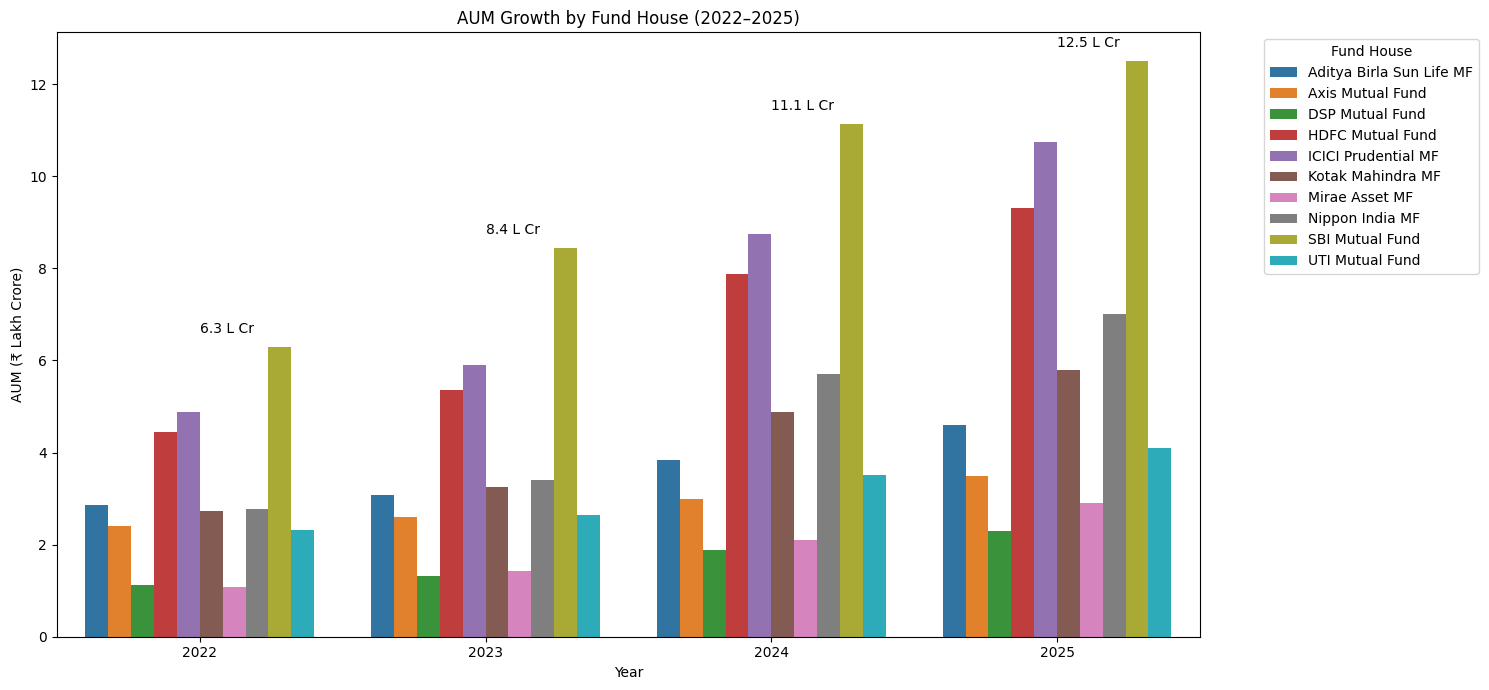

In [7]:
df['date'] = pd.to_datetime(df['date'])

df["year"] = df["date"].dt.year

df_filtered = df[df["year"].between(2022, 2025)]

aum_yearly = (
    df_filtered.sort_values("date")
    .groupby(["year", "fund_house"])
    .last()
    .reset_index()
)

plt.figure(figsize=(15,7))

sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.legend(title="Fund House", bbox_to_anchor=(1.05,1))
plt.tight_layout()

sbi = aum_yearly[
    aum_yearly["fund_house"].str.contains("SBI", case=False, na=False)
]

for _, row in sbi.iterrows():
    plt.annotate(
        f"{row['aum_lakh_crore']:.1f} L Cr",
        (row["year"] - 2022, row["aum_lakh_crore"]),
        xytext=(0, 10),
        textcoords="offset points"
    )

plt.savefig("../charts/aum_growth.png",bbox_inches="tight")

plt.show()



### Insight 3


In [8]:
sip_df = pd.read_csv('../data/processed/clean_sip_inflows.csv')
sip_df.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')

In [10]:
sip_df['month'] = pd.to_datetime(sip_df['month'])

fig = px.line(
    sip_df,
    x = 'month',
    y = 'sip_inflow_crore',
    title="Monthly SIP Inflows (Jan 2022 - Dec 2025)",
    markers=True
)

fig.add_annotation(
    x = '2025-12-31',
    y = '31002',
    text = ' ₹31,002 Cr all-time high (Dec 2025)',
    showarrow = True,
    arrowhead = 2
)

fig.write_image("../charts/sip_trend.png")

fig.show()



###  Insight 4

In [11]:
cat_df = pd.read_csv('../data/processed/clean_category_inflows.csv')
cat_df.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='object')

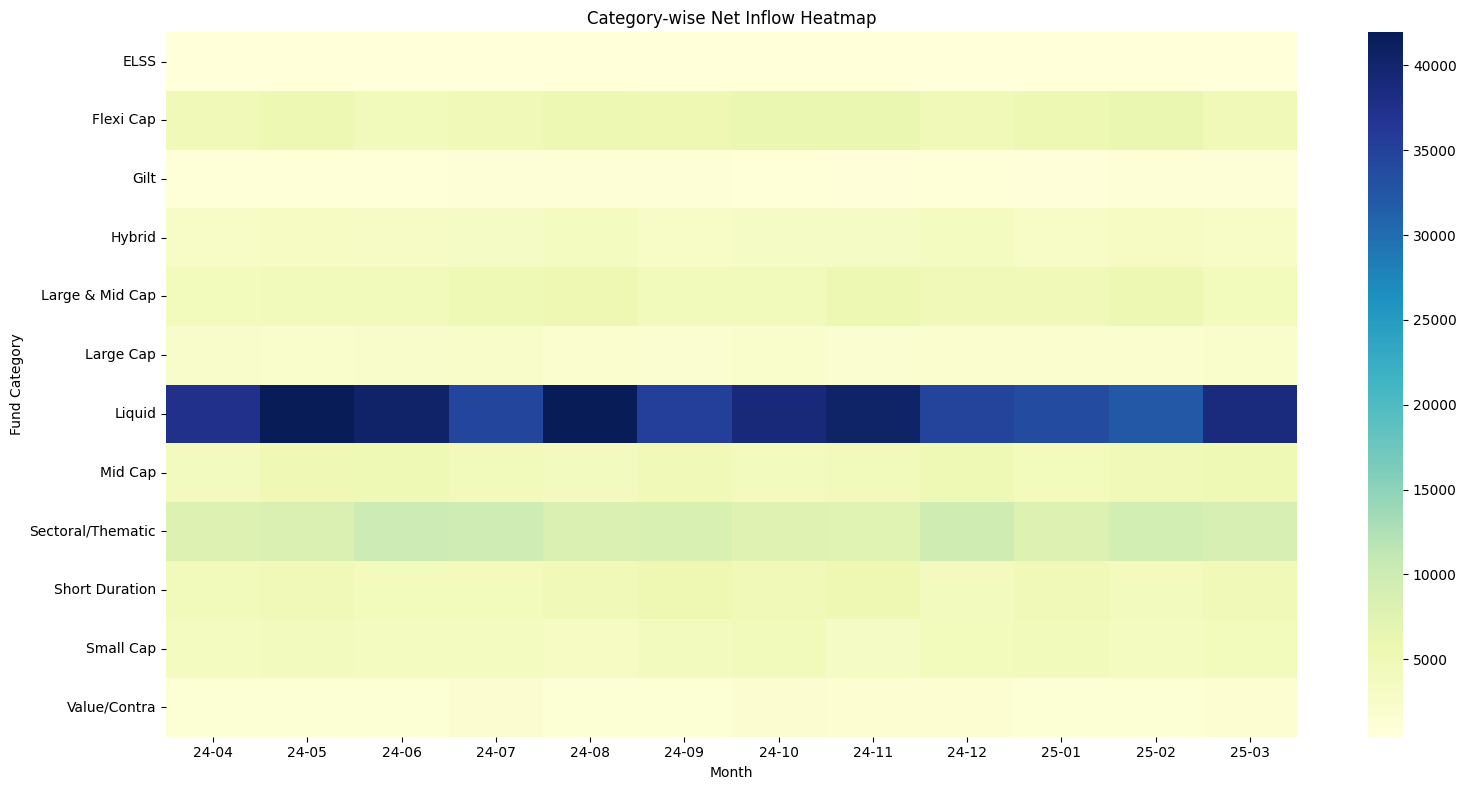

In [12]:
cat_df['month'] = pd.to_datetime(cat_df['month'])

cat_df['month_label'] = cat_df['month'].dt.strftime('%y-%m')

heatmap_data = cat_df.pivot_table(
    index="category",
    columns="month_label",
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig("../charts/category_heatmap.png",bbox_inches="tight")

plt.show()

###  Insight 5

In [13]:
txn_df = pd.read_csv('../data/processed/clean_investor_transactions.csv')
txn_df.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

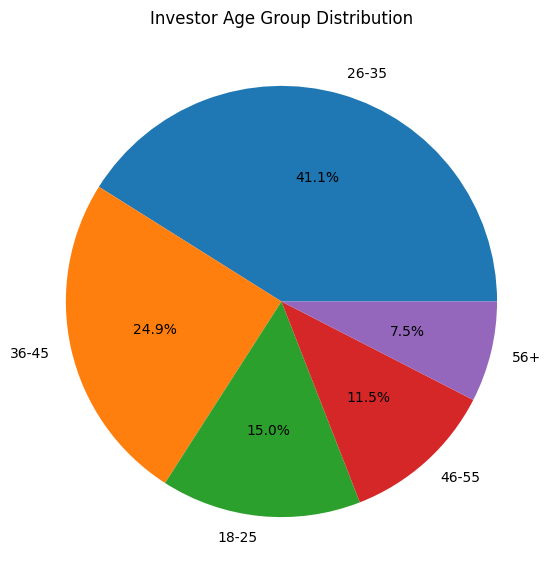

In [14]:
age_counts = txn_df["age_group"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.savefig("../charts/age_distribution.png",bbox_inches="tight")

plt.show()

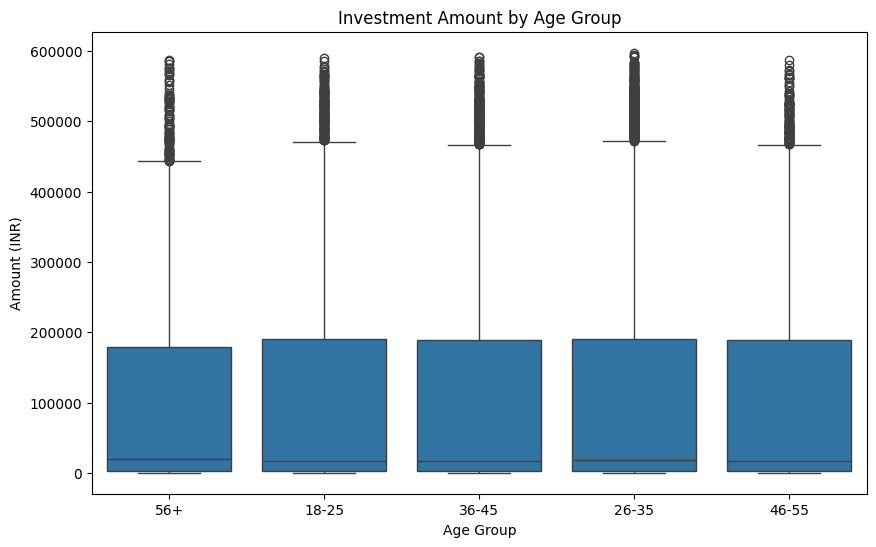

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=txn_df,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")

plt.savefig("../charts/age_group_boxplot.png",bbox_inches="tight")

plt.show()

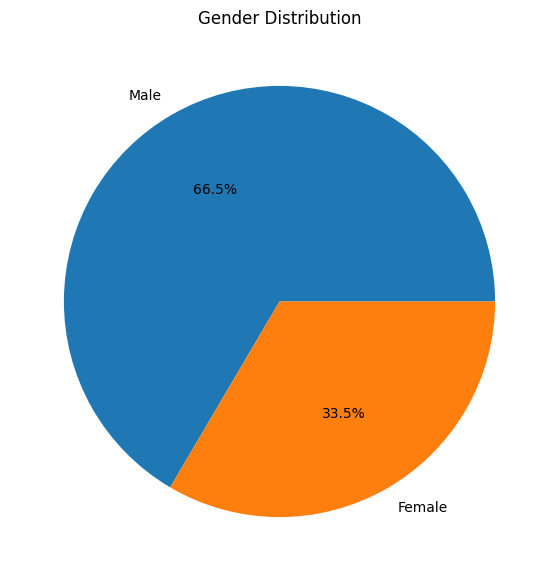

In [16]:
gender_counts = txn_df["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.savefig("../charts/gender_split.png",bbox_inches="tight")

plt.show()

### Insight 6

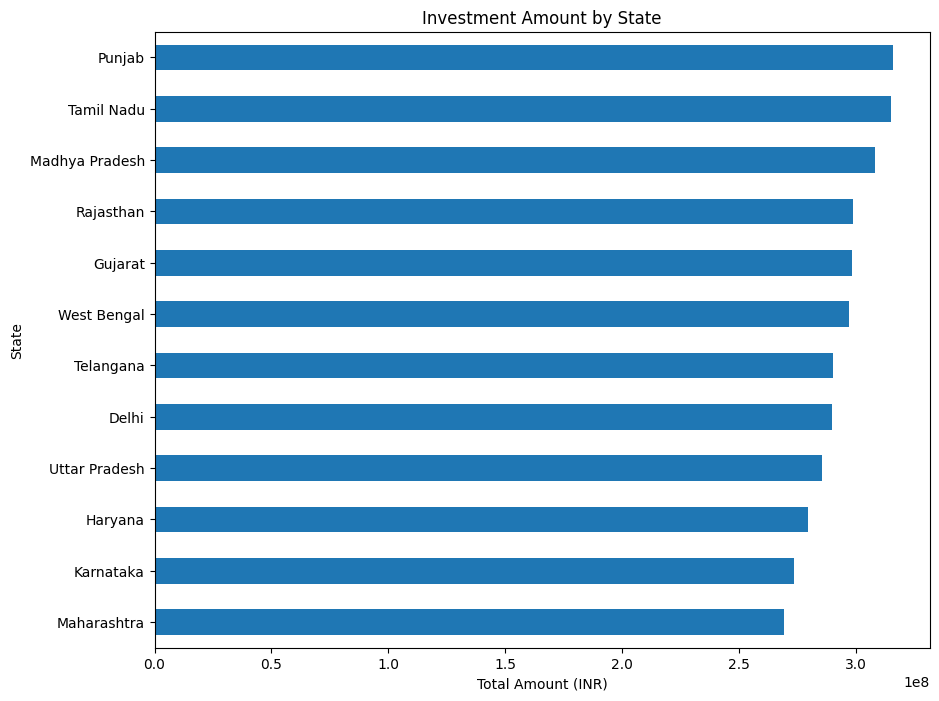

In [17]:
state_sip = (
    txn_df.groupby("state")["amount_inr"]
       .sum()
       .sort_values(ascending=True)
)

plt.figure(figsize=(10,8))

state_sip.plot(kind="barh")

plt.title("Investment Amount by State")
plt.xlabel("Total Amount (INR)")
plt.ylabel("State")

plt.savefig("../charts/state_distribution.png",bbox_inches="tight")

plt.show()

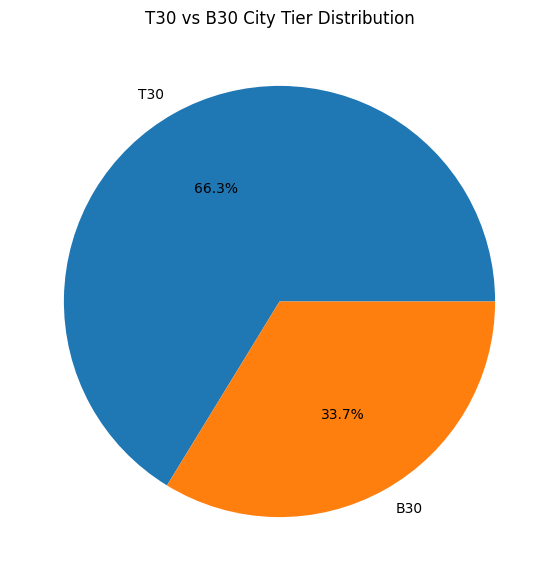

In [18]:
tier_counts = txn_df["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 City Tier Distribution")

plt.savefig("../charts/t30_b30.png",bbox_inches="tight")

plt.show()

### Insight 7

In [19]:
folo_df = pd.read_csv('../data/processed/clean_folio_growth.csv')
folo_df.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')

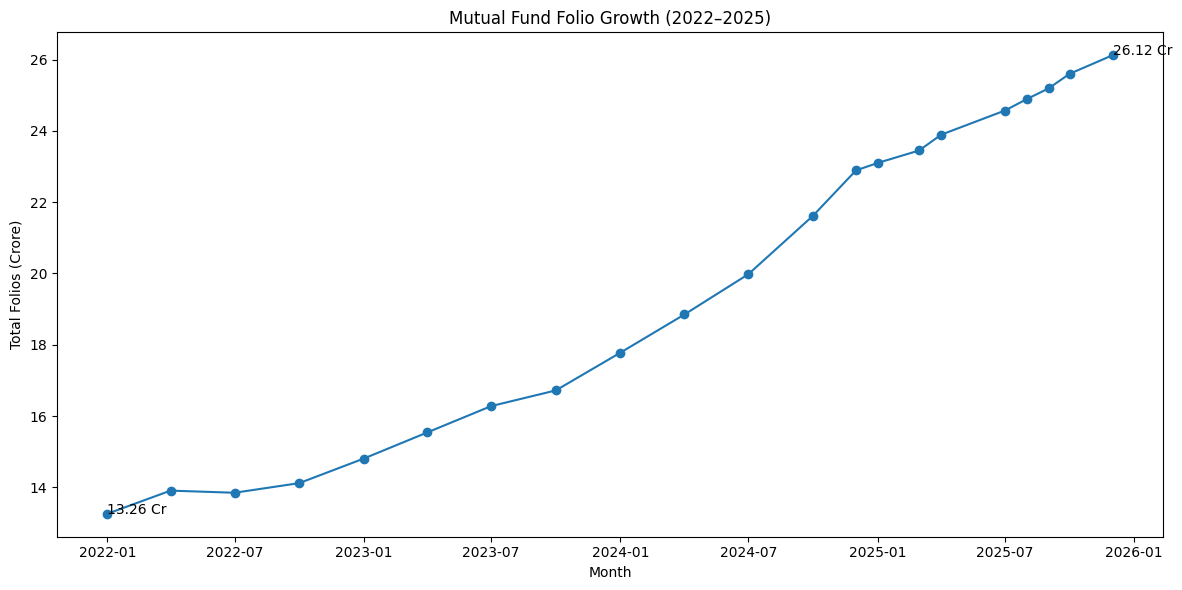

In [20]:
folo_df["month"] = pd.to_datetime(folo_df["month"])

plt.figure(figsize=(12,6))

plt.plot(folo_df["month"],folo_df["total_folios_crore"],marker="o")

plt.title("Mutual Fund Folio Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.annotate(
    f"{folo_df['total_folios_crore'].iloc[0]:.2f} Cr",
    xy=(
        folo_df["month"].iloc[0],
        folo_df["total_folios_crore"].iloc[0]
    )
)

plt.annotate(
    f"{folo_df['total_folios_crore'].iloc[-1]:.2f} Cr",
    xy=(
        folo_df["month"].iloc[-1],
        folo_df["total_folios_crore"].iloc[-1]
    )
)

plt.tight_layout()

plt.savefig("../charts/folio_growth.png",bbox_inches="tight")

plt.show()

### Insight 8

In [23]:
nav_df = pd.read_csv('../data/processed/clean_nav_history.csv')
nav_df.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

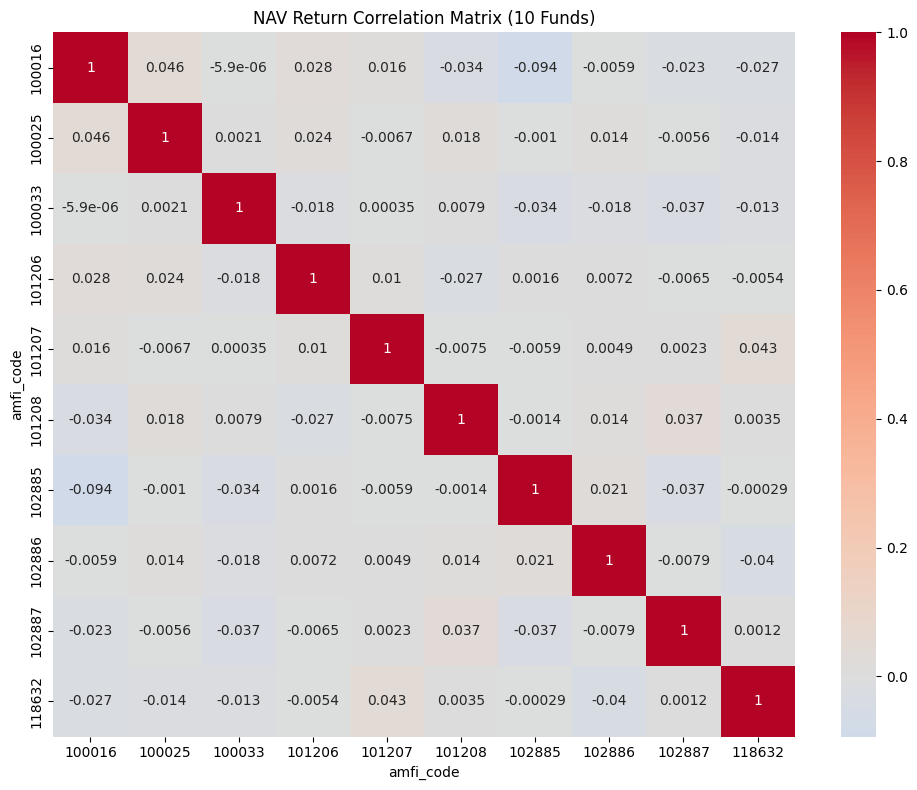

In [26]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_pivot = nav_df.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

selected_funds = nav_pivot.columns[:10]

returns = nav_pivot[selected_funds].pct_change()

corr_matrix = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("NAV Return Correlation Matrix (10 Funds)")

plt.tight_layout()

plt.savefig("../charts/nav_correlation_matrix.png",bbox_inches="tight")

plt.show()

### Insight 9

In [27]:
holdings = pd.read_csv('../data/processed/clean_portfolio_holdings.csv')
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [28]:

latest_date = holdings["portfolio_date"].max()
holdings_latest = holdings[holdings["portfolio_date"] == latest_date]

sector_alloc = (
    holdings_latest.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)
)

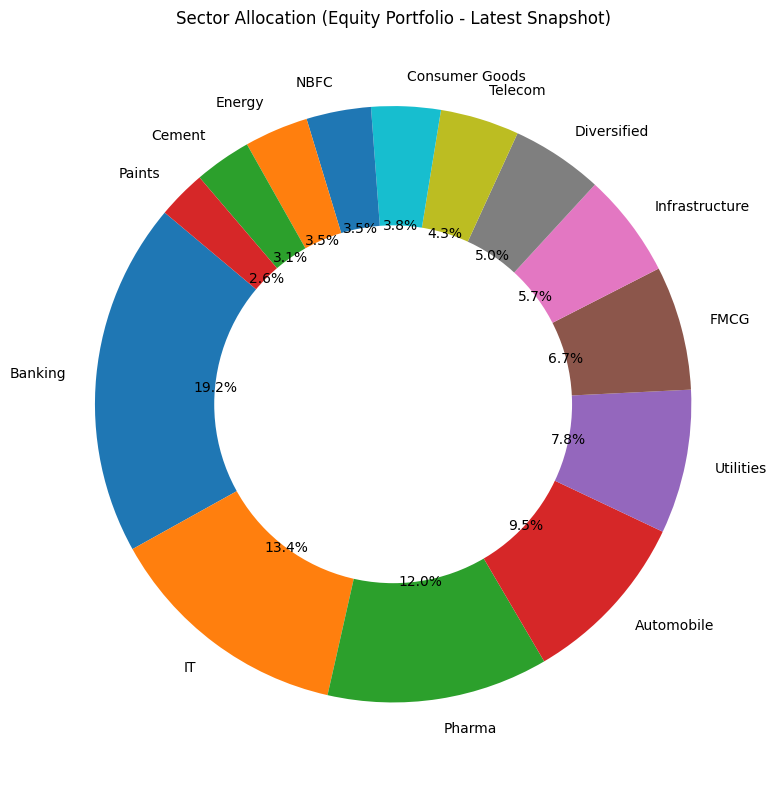

In [29]:
plt.figure(figsize=(8, 8))

plt.pie(
    sector_alloc,
    labels=sector_alloc.index,
    autopct="%1.1f%%",
    startangle=140
)

centre = plt.Circle((0, 0), 0.60, fc="white")
plt.gca().add_artist(centre)

plt.title("Sector Allocation (Equity Portfolio - Latest Snapshot)")
plt.tight_layout()

plt.savefig("../charts/sector_allocation_donut.png")
plt.show()

### Insight 10

Cell 1

Large-cap funds dominate portfolio exposure, indicating a relatively lower-risk allocation.
(chart: NAV distribution)

Cell 2

Equity funds show higher volatility compared to debt and hybrid categories.
(chart: volatility comparison)

Cell 3

NAV returns across most funds are positively correlated, reducing diversification benefits.
(chart: correlation heatmap)

Cell 4

Sector exposure is concentrated in Financials and Technology.
(chart: sector donut)

Cell 5

Hybrid funds show smoother return patterns than pure equity funds.
(chart: NAV trend)

Cell 6

Mid-cap funds have higher return fluctuations than large-cap funds.
(chart: rolling returns)

Cell 7

A small set of funds consistently outperform peers in cumulative returns.
(chart: cumulative NAV growth)

Cell 8

Portfolio holdings show overlap across multiple funds in the same sectors.
(chart: overlap / heatmap)

Cell 9

NAV movements follow clear market cycles across equity categories.
(chart: time series)

Cell 10

Higher expense ratio funds tend to show slightly weaker long-term performance.
(chart: scatter expense vs returns)